# Milestone 2: Machine Learning Modeling

This notebook applies machine learning methods to predict high-value customers using early customer purchasing behavior.

The main goal is to build predictive models that classify whether a customer is likely to become high-value based on early transaction patterns.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Basic data cleaning
df = df.dropna(subset=["Customer ID", "Invoice", "Quantity", "Price", "InvoiceDate"])

# Keep only valid purchases
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# Create total transaction value
df["TotalPrice"] = df["Quantity"] * df["Price"]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
# Find each customer's first purchase date
first_purchase = df.groupby("Customer ID")["InvoiceDate"].min().reset_index()
first_purchase.columns = ["Customer ID", "FirstPurchaseDate"]

# Merge first purchase date back into the transaction-level dataset
df = df.merge(first_purchase, on="Customer ID", how="left")

# Calculate how many days after the first purchase each transaction happened
df["DaysSinceFirstPurchase"] = (df["InvoiceDate"] - df["FirstPurchaseDate"]).dt.days

df[["Customer ID", "InvoiceDate", "FirstPurchaseDate", "DaysSinceFirstPurchase"]].head()

,Customer ID,InvoiceDate,FirstPurchaseDate,DaysSinceFirstPurchase
0,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
1,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
2,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
3,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0
4,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00,0


In [6]:
# Define early customer behavior window
early_window_days = 30

# Keep only transactions within the first 30 days after each customer's first purchase
early_df = df[df["DaysSinceFirstPurchase"] <= early_window_days]

early_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,FirstPurchaseDate,DaysSinceFirstPurchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01 08:26:00,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01 08:26:00,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,0


In [7]:
# Aggregate early behavior at customer level
early_features = early_df.groupby("Customer ID").agg({
    "Invoice": "nunique",      # number of purchases
    "TotalPrice": "sum",       # total spending
    "Quantity": "sum",         # total items purchased
    "StockCode": "nunique"     # number of unique products
}).reset_index()

# Rename columns for clarity
early_features.columns = [
    "CustomerID",
    "EarlyFrequency",
    "EarlyMonetary",
    "EarlyQuantity",
    "EarlyUniqueProducts"
]

# Create average order value
early_features["EarlyAvgOrderValue"] = early_features["EarlyMonetary"] / early_features["EarlyFrequency"]

early_features.head()

,CustomerID,EarlyFrequency,EarlyMonetary,EarlyQuantity,EarlyUniqueProducts,EarlyAvgOrderValue
0,12346.0,1,77183.60,74215,1,77183.60
1,12347.0,1,711.79,319,31,711.79
2,12348.0,1,892.80,1254,13,892.80
3,12349.0,1,1757.55,631,73,1757.55
4,12350.0,1,334.40,197,17,334.40


In [8]:
# Compute full-period monetary per customer (label side)
full_monetary = df.groupby("Customer ID")["TotalPrice"].sum().reset_index()
full_monetary.columns = ["CustomerID", "FullMonetary"]

# Define high-value threshold (top 20%)
threshold = full_monetary["FullMonetary"].quantile(0.80)

# Create label
full_monetary["HighValue"] = (full_monetary["FullMonetary"] >= threshold).astype(int)

full_monetary["HighValue"].value_counts(), threshold

(HighValue
 0    3470
 1     868
 Name: count, dtype: int64,
 np.float64(2058.426000000001))

In [9]:
# Merge early features with label
data = early_features.merge(full_monetary[["CustomerID", "HighValue"]], on="CustomerID", how="inner")

data.head(), data["HighValue"].value_counts()

(   CustomerID  EarlyFrequency  EarlyMonetary  EarlyQuantity  \
 0     12346.0               1       77183.60          74215   
 1     12347.0               1         711.79            319   
 2     12348.0               1         892.80           1254   
 3     12349.0               1        1757.55            631   
 4     12350.0               1         334.40            197   
 
    EarlyUniqueProducts  EarlyAvgOrderValue  HighValue  
 0                    1            77183.60          1  
 1                   31              711.79          1  
 2                   13              892.80          0  
 3                   73             1757.55          0  
 4                   17              334.40          0  ,
 HighValue
 0    3470
 1     868
 Name: count, dtype: int64)

In [10]:
X = data.drop(columns=["CustomerID", "HighValue"])
y = data["HighValue"]

X.head(), y.head()

(   EarlyFrequency  EarlyMonetary  EarlyQuantity  EarlyUniqueProducts  \
 0               1       77183.60          74215                    1   
 1               1         711.79            319                   31   
 2               1         892.80           1254                   13   
 3               1        1757.55            631                   73   
 4               1         334.40            197                   17   
 
    EarlyAvgOrderValue  
 0            77183.60  
 1              711.79  
 2              892.80  
 3             1757.55  
 4              334.40  ,
 0    1
 1    1
 2    0
 3    0
 4    0
 Name: HighValue, dtype: int64)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((3470, 5), (868, 5))

In [12]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8375576036866359
Precision: 0.6896551724137931
Recall: 0.3448275862068966
F1 Score: 0.45977011494252873

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       694
           1       0.69      0.34      0.46       174

    accuracy                           0.84       868
   macro avg       0.77      0.65      0.68       868
weighted avg       0.82      0.84      0.82       868



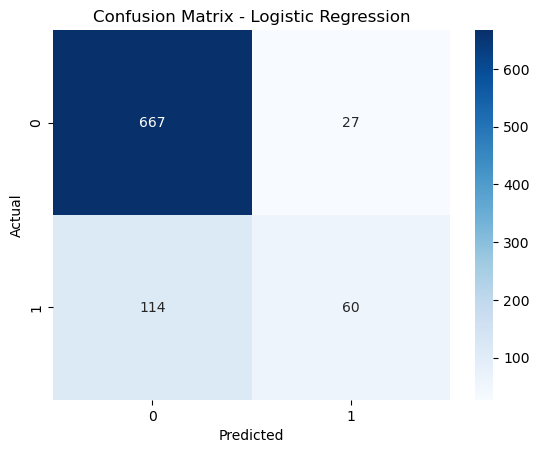

In [14]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8341013824884793
Precision: 0.6415094339622641
Recall: 0.39080459770114945
F1 Score: 0.4857142857142857

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       694
           1       0.64      0.39      0.49       174

    accuracy                           0.83       868
   macro avg       0.75      0.67      0.69       868
weighted avg       0.82      0.83      0.82       868



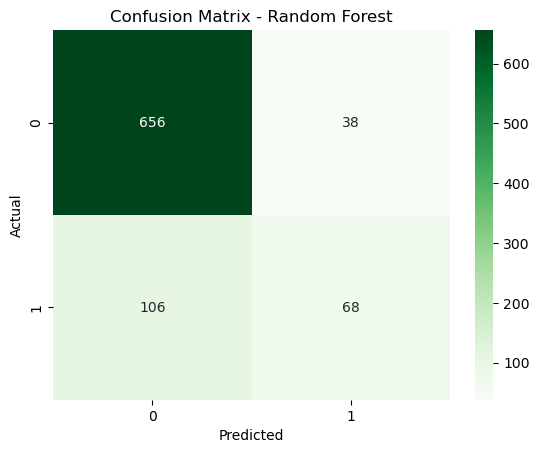

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

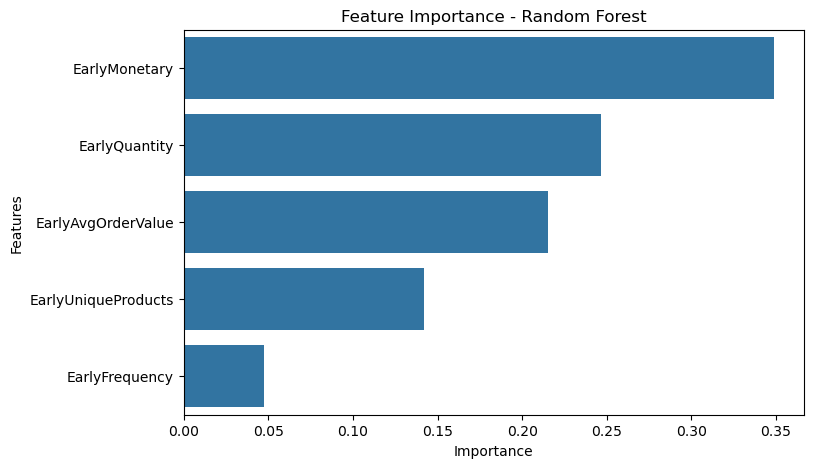

EarlyMonetary          0.348861
EarlyQuantity          0.246631
EarlyAvgOrderValue     0.215267
EarlyUniqueProducts    0.141833
EarlyFrequency         0.047409
dtype: float64

In [18]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

importances